In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Data Pre-proceesing

In [2]:
dataset=pd.read_csv("housing.csv")

In [3]:
dataset

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
#Handling missing values(if any)
dataset.dropna(inplace=True)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


# Model Training and evaluation

In [7]:

x=dataset.drop(['median_house_value'],axis=1)
y=dataset['median_house_value']

In [ ]:

le = preprocessing.LabelEncoder()
le.fit(x['ocean_proximity'])

x['ocean_proximity'] = le.transform(x['ocean_proximity'])

x


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,1


In [67]:
import pickle

with open('label_encoder_ocean.pkl','wb') as file:
    pickle.dump(le,file)

In [9]:
x

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,1


In [10]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20433, dtype: float64

In [71]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [72]:
x_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
17022,-122.31,37.52,24.0,2328.0,335.0,969.0,354.0,7.7364,4
16711,-120.50,35.03,10.0,10463.0,1756.0,4660.0,1715.0,3.5682,0
11768,-121.30,38.73,9.0,5558.0,1099.0,2717.0,1043.0,3.6455,1
11715,-120.12,39.18,17.0,2839.0,525.0,390.0,189.0,3.5667,1
1574,-122.03,37.83,24.0,5948.0,738.0,1997.0,710.0,9.8708,3
...,...,...,...,...,...,...,...,...,...
258,-122.20,37.77,39.0,2689.0,597.0,1888.0,537.0,2.2562,3
7529,-118.23,33.91,33.0,677.0,182.0,984.0,174.0,2.5893,0
2370,-119.57,36.70,34.0,1759.0,354.0,899.0,337.0,2.6823,1
8506,-118.30,33.88,30.0,1348.0,333.0,885.0,322.0,3.2574,0


In [73]:
y_train

17022    435800.0
16711    277300.0
11768    139200.0
11715    179200.0
1574     500001.0
           ...   
258       94800.0
7529      88900.0
2370      72900.0
8506     195300.0
7907     286500.0
Name: median_house_value, Length: 16346, dtype: float64

In [74]:
x_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
10668,-117.84,33.60,21.0,4281.0,582.0,1443.0,576.0,9.0519,0
14966,-117.00,32.74,17.0,2357.0,599.0,1423.0,510.0,1.8856,0
12313,-116.57,33.64,10.0,489.0,82.0,183.0,74.0,6.2702,1
14787,-117.13,32.58,27.0,2511.0,615.0,1427.0,576.0,3.1645,4
14838,-117.10,32.68,49.0,1412.0,350.0,1200.0,332.0,2.0398,4
...,...,...,...,...,...,...,...,...,...
17440,-120.44,34.66,22.0,3231.0,549.0,1739.0,581.0,4.5417,4
4649,-118.31,34.06,14.0,1559.0,646.0,1639.0,567.0,1.9949,0
6565,-118.14,34.19,45.0,3595.0,619.0,1686.0,607.0,4.7300,1
18758,-122.36,40.66,17.0,2786.0,559.0,1528.0,517.0,2.0119,1


In [75]:
y_test

10668    500001.0
14966    118800.0
12313    345500.0
14787    156000.0
14838     93600.0
           ...   
17440    142400.0
4649     380000.0
6565     201000.0
18758     75800.0
20126    375000.0
Name: median_house_value, Length: 4087, dtype: float64

In [16]:
train_dataset=x_train.join(y_train)

In [17]:
train_dataset

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
3245,-119.57,36.10,37.0,1676.0,316.0,707.0,274.0,2.0595,1,60700.0
1081,-121.84,39.73,52.0,502.0,100.0,311.0,100.0,1.5481,1,200000.0
9046,-118.10,34.65,33.0,873.0,177.0,425.0,142.0,2.6700,1,187500.0
6107,-117.90,34.11,37.0,1286.0,255.0,1047.0,249.0,4.2019,0,140100.0
1439,-122.01,37.97,32.0,3012.0,527.0,1288.0,512.0,3.6449,3,211500.0
...,...,...,...,...,...,...,...,...,...,...
14922,-116.98,32.62,6.0,7995.0,1458.0,4771.0,1376.0,4.7068,4,184300.0
1743,-122.35,37.96,29.0,1899.0,524.0,1357.0,443.0,1.8750,3,97200.0
5328,-118.45,34.04,23.0,3771.0,1321.0,2031.0,1241.0,2.7679,0,277500.0
11887,-117.36,33.98,46.0,1680.0,453.0,1570.0,435.0,2.0436,1,82300.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'ocean_proximity'}>],
       [<Axes: title={'center': 'median_house_value'}>, <Axes: >,
        <Axes: >]], dtype=object)

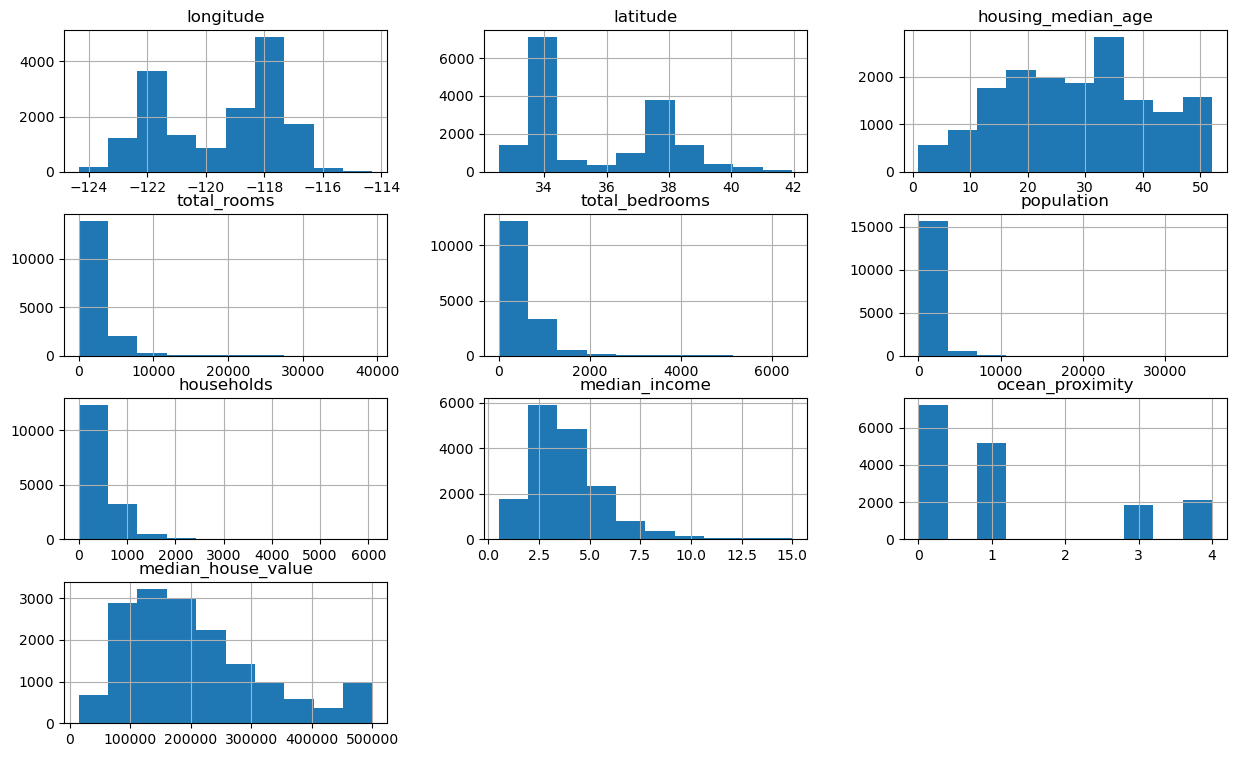

In [18]:
train_dataset.hist(figsize=(15,9))

In [19]:
train_dataset.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
longitude,1.000000,-0.923841,-0.109322,0.046393,0.070451,0.099348,0.057106,-0.016877,-0.298659,-0.047764
latitude,-0.923841,1.000000,0.012980,-0.038704,-0.069095,-0.109463,-0.074589,-0.077086,0.208507,-0.142159
housing_median_age,-0.109322,0.012980,1.000000,-0.358877,-0.317319,-0.291464,-0.299532,-0.120703,0.107894,0.101837
total_rooms,0.046393,-0.038704,-0.358877,1.000000,0.929564,0.853048,0.916929,0.200573,-0.020652,0.141065
total_bedrooms,0.070451,-0.069095,-0.317319,0.929564,1.000000,0.873023,0.978805,-0.007421,-0.017235,0.055306
population,0.099348,-0.109463,-0.291464,0.853048,0.873023,1.000000,0.903794,0.006768,-0.074580,-0.020816
households,0.057106,-0.074589,-0.299532,0.916929,0.978805,0.903794,1.000000,0.014121,-0.020415,0.072044
median_income,-0.016877,-0.077086,-0.120703,0.200573,-0.007421,0.006768,0.014121,1.000000,-0.021144,0.689679
ocean_proximity,-0.298659,0.208507,0.107894,-0.020652,-0.017235,-0.074580,-0.020415,-0.021144,1.000000,0.075694
median_house_value,-0.047764,-0.142159,0.101837,0.141065,0.055306,-0.020816,0.072044,0.689679,0.075694,1.000000


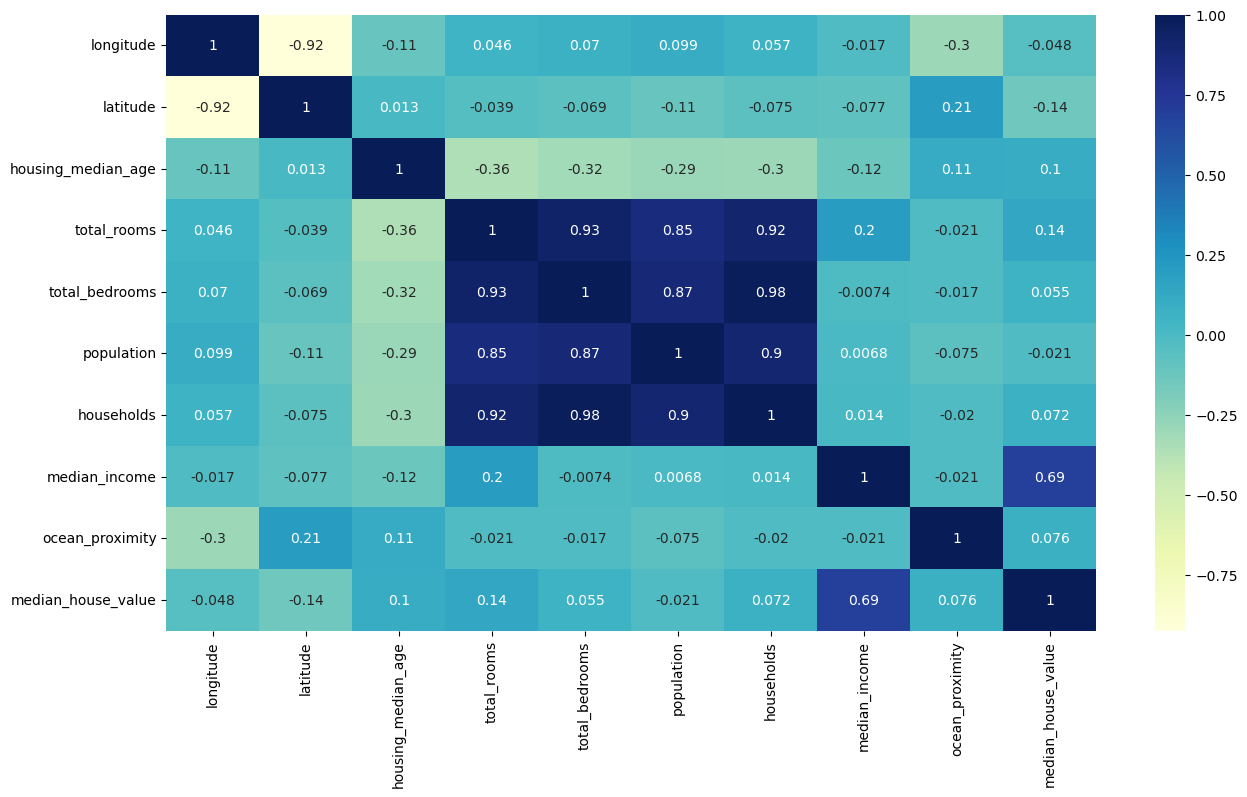

In [20]:
#Correlation matrix between input features

plt.figure(figsize=(15,8))
sns.heatmap(train_dataset.corr(),annot=True,cmap='YlGnBu')
plt.show()

In [21]:
train_dataset['total_rooms']=np.log(train_dataset['total_rooms'] + 1)
train_dataset['total_bedrooms']=np.log(train_dataset['total_bedrooms'] + 1)
train_dataset['population']=np.log(train_dataset['population'] + 1)
train_dataset['households']=np.log(train_dataset['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'ocean_proximity'}>],
       [<Axes: title={'center': 'median_house_value'}>, <Axes: >,
        <Axes: >]], dtype=object)

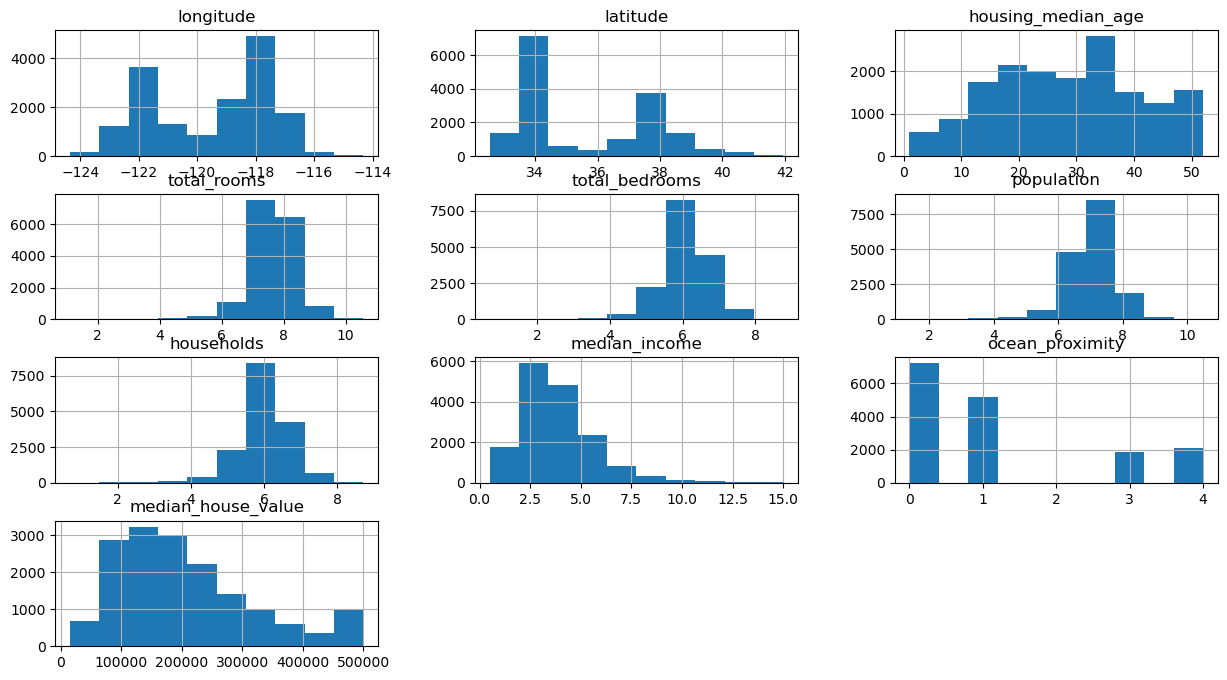

In [22]:
train_dataset.hist(figsize=(15,8))

In [23]:
train_dataset.ocean_proximity.value_counts()

ocean_proximity
0    7230
1    5172
4    2090
3    1850
2       4
Name: count, dtype: int64

<Axes: xlabel='latitude', ylabel='longitude'>

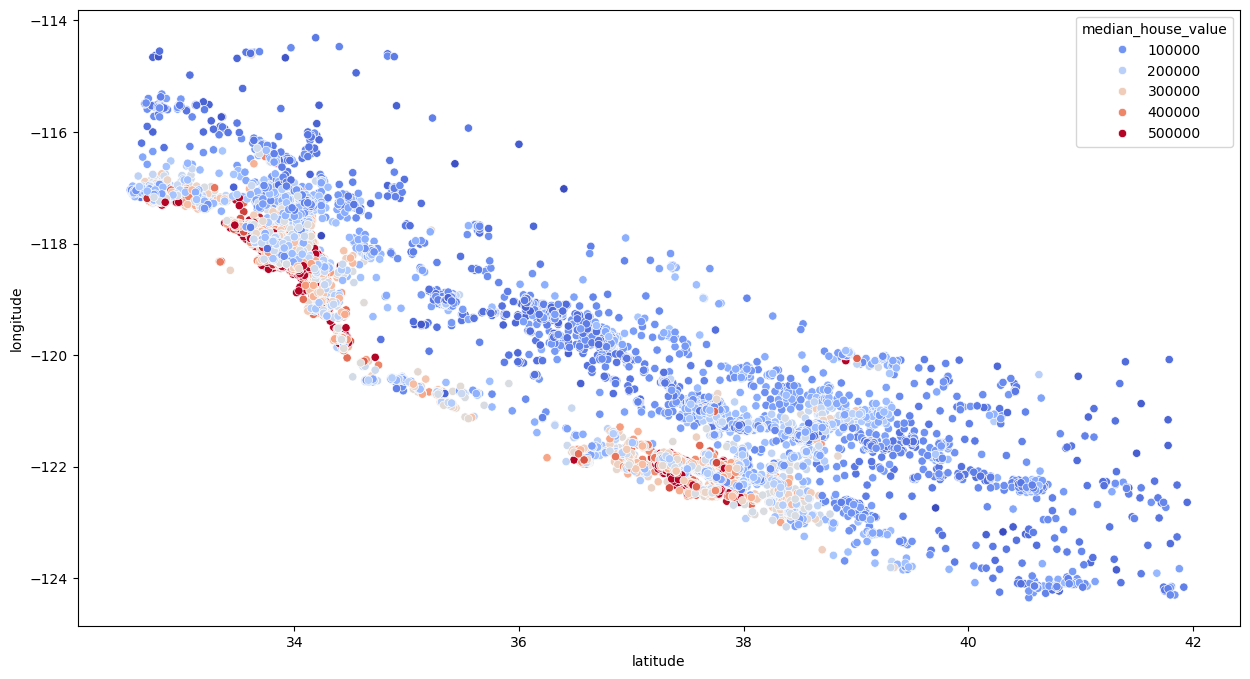

In [24]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='latitude',y='longitude' , data=train_dataset, hue='median_house_value',palette='coolwarm')

<Axes: >

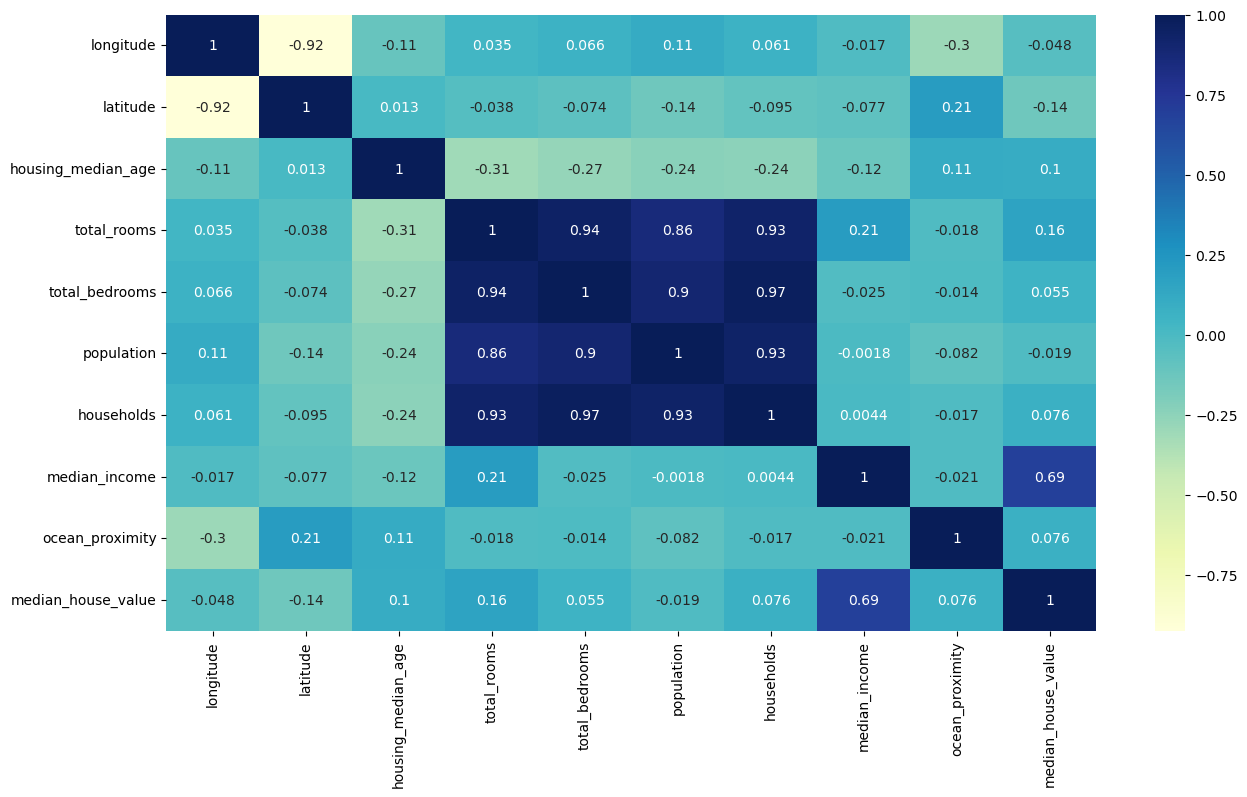

In [25]:
plt.figure(figsize=(15,8))
sns.heatmap(train_dataset.corr(),annot=True,cmap='YlGnBu')

In [76]:
'''
le = preprocessing.LabelEncoder()
le.fit(x_train['ocean_proximity'])

x_train['ocean_proximity'] = le.transform(x_train['ocean_proximity'])

x_train'''


"\nle = preprocessing.LabelEncoder()\nle.fit(x_train['ocean_proximity'])\n\nx_train['ocean_proximity'] = le.transform(x_train['ocean_proximity'])\n\nx_train"

In [28]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [78]:
with open('scaler.pkl','wb') as file:
    pickle.dump(scaler,file)

In [29]:
x_train

array([[ 0.0062517 ,  0.21383536,  0.66541849, ..., -0.59114469,
        -0.94751738, -0.11817643],
       [-1.12575973,  1.91374792,  1.85792491, ..., -1.04746455,
        -1.21471328, -0.11817643],
       [ 0.73931636, -0.46519308,  0.34741677, ..., -0.93731838,
        -0.62854379, -0.11817643],
       ...,
       [ 0.56477716, -0.75085332, -0.44758751, ...,  1.94483984,
        -0.57739307, -0.8221531 ],
       [ 1.10834212, -0.77895105,  1.38092234, ..., -0.16891769,
        -0.9558248 , -0.11817643],
       [ 0.74929003, -0.81173173,  0.10891549, ..., -0.23448089,
        -1.50390555, -0.8221531 ]])

# linear regressor

In [30]:

regressor = LinearRegression() # this is the model
regressor.fit(x_train, y_train)

LinearRegression()

In [31]:
lr_y_pred = regressor.predict(x_test)
lr_y_pred

array([  9674.05033322, 199635.73832197, 302974.98237527, ...,
       213269.15843392, 232370.61648305, 119621.09849841])

In [32]:
# from sklearn.metrics import regressor_score
# regressor.score(x_test,y_test)


lr_rmse = np.sqrt(mean_squared_error(y_test, lr_y_pred))

In [33]:
lr_rmse

70369.39864250438

In [34]:
lr_r2 = r2_score(y_test,lr_y_pred)
lr_r2

0.6296412700813381

# Support Vector Regression(SVR)

In [35]:

svr_regressor = SVR(kernel='linear')
svr_regressor.fit(x_train, y_train)


svr_y_pred = svr_regressor.predict(x_test)


svr_rmse = np.sqrt(mean_squared_error(y_test, svr_y_pred))
svr_r2 = r2_score(y_test, svr_y_pred)

In [36]:
svr_rmse


112510.21245774339

In [37]:
svr_r2

0.053242408219165815

# K-Nearest Neighbors(KNN)

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': range(1,30)}
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='r2')
grid_search.fit(x_train, y_train)
best_n_neighbors = grid_search.best_params_['n_neighbors']

In [39]:
print(best_n_neighbors)

11


In [40]:

knn_regressor = KNeighborsRegressor(n_neighbors=11)  # You can try different values for n_neighbors
knn_regressor.fit(x_train, y_train)


knn_y_pred = knn_regressor.predict(x_test)


knn_rmse = np.sqrt(mean_squared_error(y_test, knn_y_pred))
knn_r2 = r2_score(y_test, knn_y_pred)

In [41]:
knn_rmse

61061.47834314457

In [42]:
knn_r2

0.7211378726871673

# random forest regressor

In [43]:

from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(n_estimators = 50, random_state = 0)


rf_regressor.fit(x_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=0)

In [44]:
rf_y_pred = rf_regressor.predict(x_test)
rf_y_pred

array([ 98952.  , 273444.  , 274234.04, ..., 285692.  , 188148.  ,
        75100.  ])

In [45]:

rf_mse = mean_squared_error(y_true=y_test, y_pred=rf_y_pred)
rf_rmse = np.sqrt(rf_mse)

In [46]:
rf_rmse

50930.63823253206

In [47]:
rf_r2 = r2_score(y_test,rf_y_pred)
rf_r2

0.8059949013458215

# xgboost regressor

In [48]:
# import os

In [49]:
# os.system("pip install xgboost")

In [52]:
#extreme gradient boosting
import xgboost as xgb

In [53]:
xg_regressor = xgb.XGBRegressor(n_estimators = 50, random_state=0)
xg_regressor.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [80]:
with open('xgb_model.pkl','wb') as file:
    pickle.dump(xg_regressor,file)

In [54]:
xg_y_pred=xg_regressor.predict(x_test)
xg_y_pred

array([ 94151.1 , 244423.39, 251289.31, ..., 281920.03, 214011.94,
        69680.92], dtype=float32)

In [55]:

xg_mse = mean_squared_error(y_true=y_test, y_pred=xg_y_pred)
xg_rmse = np.sqrt(xg_mse)

In [56]:
xg_rmse

50014.43414481168

In [57]:
xg_r2 = r2_score(y_test,xg_y_pred)
xg_r2

0.8129121319706217

# Model Comparison

In [58]:
import pandas as pd

data = {'Model': ['Linear Regression', 'Random Forest', 'XGBoost','SVR','KNN'],
        'RMSE': [lr_rmse, rf_rmse, xg_rmse,svr_rmse,knn_rmse],
        'R-squared': [lr_r2, rf_r2, xg_r2,svr_r2,knn_r2]}

comparison_df = pd.DataFrame(data)
print(comparison_df)

               Model           RMSE  R-squared
0  Linear Regression   70369.398643   0.629641
1      Random Forest   50930.638233   0.805995
2            XGBoost   50014.434145   0.812912
3                SVR  112510.212458   0.053242
4                KNN   61061.478343   0.721138


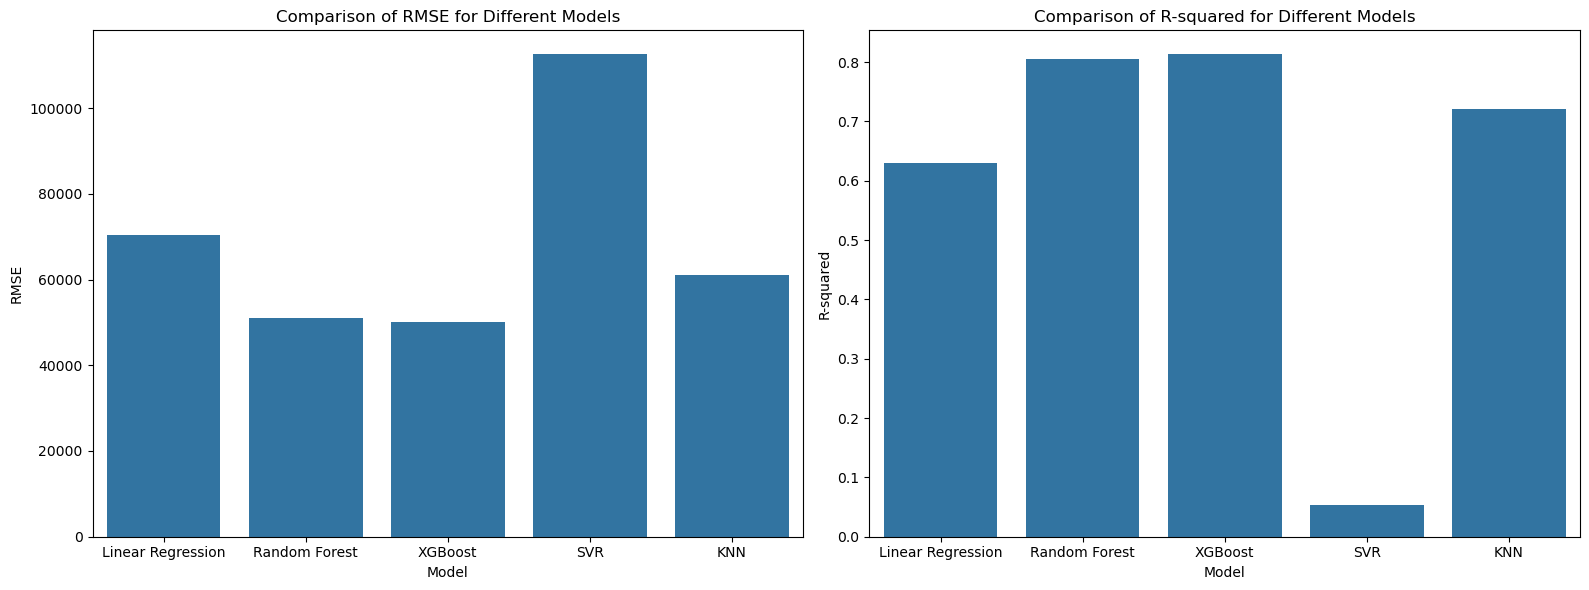

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot for RMSE on the first subplot (axes[0])
sns.barplot(x='Model', y='RMSE', data=comparison_df, ax=axes[0])
axes[0].set_title('Comparison of RMSE for Different Models')


# Bar plot for R-squared on the second subplot (axes[1])
sns.barplot(x='Model', y='R-squared', data=comparison_df, ax=axes[1])
axes[1].set_title('Comparison of R-squared for Different Models')


plt.tight_layout()
plt.show()

In [60]:
# Calculate feature ranges from the dataset
feature_ranges = []
for column in dataset.columns[:-1]:  # Exclude the target column ('median_house_value')
    min_val = dataset[column].min()
    max_val = dataset[column].max()
    feature_ranges.append((min_val, max_val))

# Generate a random input array within the calculated ranges
input_array = np.array([np.random.uniform(low, high) for low, high in feature_ranges])

# Apply the same preprocessing as in the training code
# Create a copy of the dataset to avoid modifying the original
preprocessed_dataset = dataset.copy()

le = preprocessing.LabelEncoder()
le.fit(preprocessed_dataset['ocean_proximity'])
preprocessed_dataset['ocean_proximity'] = le.transform(preprocessed_dataset['ocean_proximity'])

# Transform the input_array's 'ocean_proximity' value
input_array[4] = le.transform([np.random.choice(dataset['ocean_proximity'].unique())])[0]

# Apply scaling if used during training
scaler = StandardScaler()
# Fit on the preprocessed data (with 'ocean_proximity' encoded)
scaler.fit(preprocessed_dataset.drop(['median_house_value'], axis=1))
input_array = scaler.transform(input_array.reshape(1, -1))[0]  # Reshape and transform

print(input_array)

[ 1.47057337e+00  1.31824099e+00  5.05420841e-01  1.16230418e+01
 -1.26934645e+00  2.19367063e+01  1.06353465e+00  3.22597071e-02
  3.08758989e+05]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [61]:
base_models = [
    ('rf', RandomForestRegressor(n_estimators=50, random_state=0)),
    ('xgb', xgb.XGBRegressor(n_estimators=50, random_state=0)),
    # Add more base models if desired
]

meta_learner = LinearRegression()  # Or any other suitable model

In [62]:
from sklearn.ensemble import StackingRegressor

stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=10  # Number of cross-validation folds
)

In [63]:
stacking_regressor.fit(x_train, y_train)

StackingRegressor(cv=10,
                  estimators=[('rf',
                               RandomForestRegressor(n_estimators=50,
                                                     random_state=0)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, g...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=50, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                  final_estimator=LinearRegression())

In [64]:
stacking_predictions = stacking_regressor.predict(x_test)

In [65]:
stacking_rmse = np.sqrt(mean_squared_error(y_test, stacking_predictions))
stacking_r2 = r2_score(y_test, stacking_predictions)
print(f"Stacking RMSE: {stacking_rmse}")
print(f"Stacking R-squared: {stacking_r2}")

Stacking RMSE: 48686.80318482951
Stacking R-squared: 0.8227127818643247


In [66]:
x_test.shape

(4087, 9)

In [ ]:
print(y_test.iloc[val])

241600.0
